<span style="font-size: 12px;">

# Assignment 1: Solving a Customer Problem Using SVD / LSA
## Real Dataset: CFPB Consumer Financial Complaints

---

| Property | Detail |
|---|---|
| **Dataset** | Consumer Financial Protection Bureau (CFPB) Complaints |
| **Source** | [Kaggle — CFPB Consumer Complaints](https://www.kaggle.com/datasets/selener/consumer-complaint-database) |
| **Technique** | Latent Semantic Analysis (LSA) via Singular Value Decomposition (SVD) |
| **Goal** | Automatically discover hidden complaint topics & find similar issues |

---
</span>

###  Section 1 — Understanding the Customer Problem

<span style="font-size: 12px;">

### Business Scenario

> *"We receive thousands of financial complaints every week. We cannot manually read all of them. We need a system to automatically discover the main complaint topics and group similar issues together."*

### What Type of Company Faces This Problem?

| Industry | Complaint Source |
|---|---|
| **Banks & Credit Unions** | Account errors, fraud, overdraft fees |
| **Credit Card Companies** | Billing disputes, interest rate issues |
| **Mortgage Lenders** | Loan modification, foreclosure complaints |
| **Student Loan Servicers** | Repayment errors, deferment issues |
| **Debt Collectors** | Harassment, incorrect debt amounts |

### Why Analysing Customer Text Is Critical

1. **Volume** — Thousands of complaints per week cannot be read manually
2. **Prioritisation** — Identify the most urgent recurring issues automatically
3. **Pattern Detection** — Discover if 500 complaints describe the same underlying problem
4. **Regulatory Compliance** — Financial institutions must respond to complaints quickly
5. **Product Improvement** — Topic trends reveal which products or policies need fixing

### How LSA Solves This

LSA uses SVD to discover **hidden semantic topics** in unstructured text — without any labels.  
Words like `interest`, `rate`, `charge`, `fee` automatically cluster into the same latent topic even if complaints are phrased differently.



### Section 2 — Dataset Loading

<span style="font-size: 12px;">


### About the Dataset

The **CFPB Consumer Complaints Database** is a real, publicly available dataset published by the U.S. Consumer Financial Protection Bureau.

| Property | Value |
|---|---|
| **Source** | Consumer Financial Protection Bureau (CFPB) |
| **Kaggle Link** | https://www.kaggle.com/datasets/selener/consumer-complaint-database |
| **Text Column** | `Consumer complaint narrative` |
| **Category Column** | `Product` |
| **Document Type** | Real customer financial complaints |



In [ ]:
# Importing Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import plotly.express as px
import seaborn as sns


import re
import math
import warnings
warnings.filterwarnings("ignore")
from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

import subprocess
subprocess.run(["python", "-m", "spacy", "download", "en_core_web_sm"], capture_output=True)
import spacy
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d selener/consumer-complaint-database --unzip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/selener/consumer-complaint-database
License(s): U.S. Government Works
100% 176M/176M [00:01<00:00, 127MB/s]



In [ ]:
df_raw = pd.read_csv("rows.csv", low_memory=False)

In [ ]:
df_raw.shape

(1282355, 18)

In [ ]:
df_raw.columns

Index(['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue',
       'Consumer complaint narrative', 'Company public response', 'Company',
       'State', 'ZIP code', 'Tags', 'Consumer consent provided?',
       'Submitted via', 'Date sent to company', 'Company response to consumer',
       'Timely response?', 'Consumer disputed?', 'Complaint ID'],
      dtype='object')

In [ ]:
df_raw.head()

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,05/10/2019,Checking or savings account,Checking account,Managing an account,Problem using a debit or ATM card,NaN,NaN,NAVY FEDERAL CREDIT UNION,FL,328XX,Older American,NaN,Web,05/10/2019,In progress,Yes,NaN,3238275
1,05/10/2019,Checking or savings account,Other banking product or service,Managing an account,Deposits and withdrawals,NaN,NaN,BOEING EMPLOYEES CREDIT UNION,WA,98204,NaN,NaN,Referral,05/10/2019,Closed with explanation,Yes,NaN,3238228
2,05/10/2019,Debt collection,Payday loan debt,Communication tactics,Frequent or repeated calls,NaN,NaN,CURO Intermediate Holdings,TX,751XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3237964
3,05/10/2019,"Credit reporting, credit repair services, or o...",Credit reporting,Incorrect information on your report,Old information reappears or never goes away,NaN,NaN,Ad Astra Recovery Services Inc,LA,708XX,NaN,NaN,Web,05/10/2019,Closed with explanation,Yes,NaN,3238479
4,05/10/2019,Checking or savings account,Checking account,Managing an account,Banking errors,NaN,NaN,ALLY FINANCIAL INC.,AZ,85205,NaN,NaN,Postal mail,05/10/2019,In progress,Yes,NaN,3238460


In [ ]:
print("Missing values in each column:")
(df_raw.isna().sum()/ df_raw.shape[0]) * 100

Missing values in each column:


,0
Date received,0.000000
Product,0.000000
Sub-product,18.338604
Issue,0.000000
Sub-issue,41.422695
Consumer complaint narrative,70.089094
Company public response,64.979900
Company,0.000000
State,1.512842
ZIP code,8.991114


In [ ]:
df_raw = df_raw[["Consumer complaint narrative", "Product"]].dropna()
df_raw.columns = ["text", "category"]

In [ ]:
df_raw.shape

(383564, 2)

In [ ]:
df_raw.head()

,text,category
29904,The Summer of XX/XX/2018 I was denied a mortga...,"Credit reporting, credit repair services, or o..."
30629,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."
30735,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."
30795,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."
30807,There are many mistakes appear in my report wi...,"Credit reporting, credit repair services, or o..."


### Section 3 — Data Understanding

We now examine the loaded dataset to understand its structure before any analysis.


In [ ]:
print(f"Total documents: {len(df_raw):,}")
print(f"Columns: {list(df_raw.columns)}")
print(f"Unique categories: {df_raw['category'].nunique()}")

Total documents: 383,564
Columns: ['text', 'category']
Unique categories: 18


In [ ]:
print("Category distribution:")
print(df_raw["category"].value_counts().to_string())

Category distribution:
category
Credit reporting, credit repair services, or other personal consumer reports    92378
Debt collection                                                                 86710
Mortgage                                                                        52987
Credit reporting                                                                31588
Student loan                                                                    21810
Credit card or prepaid card                                                     21379
Credit card                                                                     18838
Bank account or service                                                         14885
Checking or savings account                                                     12881
Consumer Loan                                                                    9474
Vehicle loan or lease                                                            5745
Money transfer, virtua

In [ ]:
print(df_raw.sample(3)[["category", "text"]].to_string(
        max_colwidth=120))

                           category                                                                                                                     text
654329                  Credit card                                                             Barclays will not remove old information on my credit report
638119                  Credit card  In XX/XX/XXXX I had a Sam 's credit card that I have never been late on since XX/XX/XXXX. I make very big payments o...
133543  Credit card or prepaid card  I have Direct Deposit with Netspend ( XXXX ). My job sent direct deposit for {$6100.00} on XX/XX/18. XXXX received o...


### Section 4 — Exploratory Data Analysis (EDA)

<span style="font-size: 14px;">

### What We Explore

1. **Category distribution** — Is the dataset balanced across complaint types?
2. **Document lengths** — Are complaints long enough for meaningful analysis?
3. **Most frequent words** — What themes dominate before preprocessing?

### Why This Matters

- Imbalanced categories bias SVD toward over-represented topics
- Very short documents (< 20 words) don't provide enough signal for latent analysis
- Dominant raw words reveal what kind of preprocessing is needed


In [ ]:
lengths = df_raw["text"].apply(lambda x: len(str(x).split()))

In [ ]:
cat_counts = df_raw["category"].value_counts()

In [ ]:
all_words = " ".join(df_raw["text"].astype(str)).lower().split()

In [ ]:
top30 = Counter(all_words).most_common(30)
words, counts = zip(*top30)

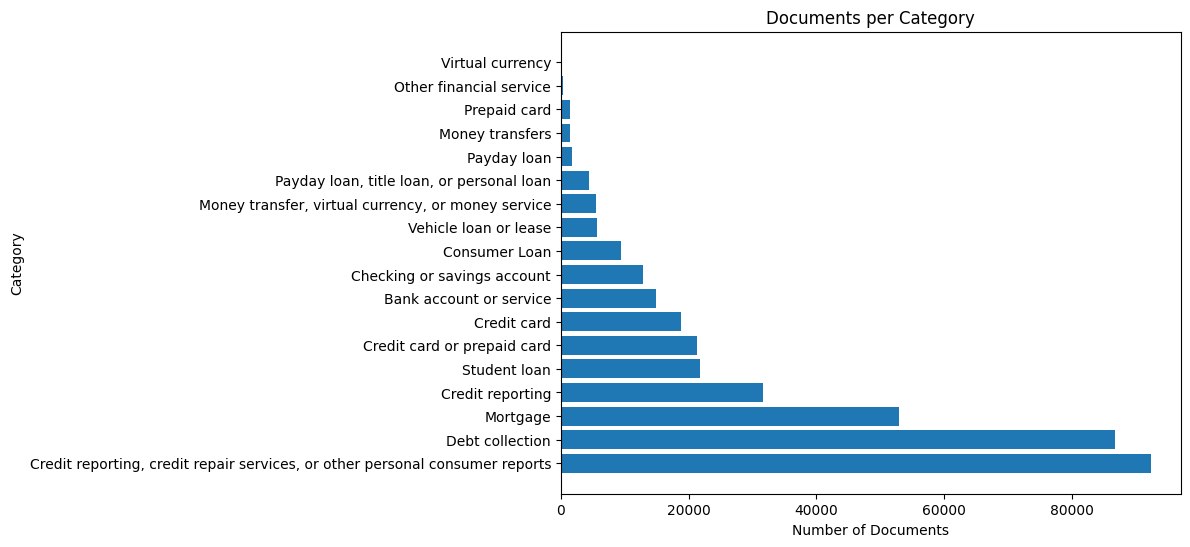

In [ ]:
plt.figure(figsize=(8,6))

plt.barh(cat_counts.index, cat_counts.values)

plt.title("Documents per Category")
plt.xlabel("Number of Documents")
plt.ylabel("Category")
plt.show()

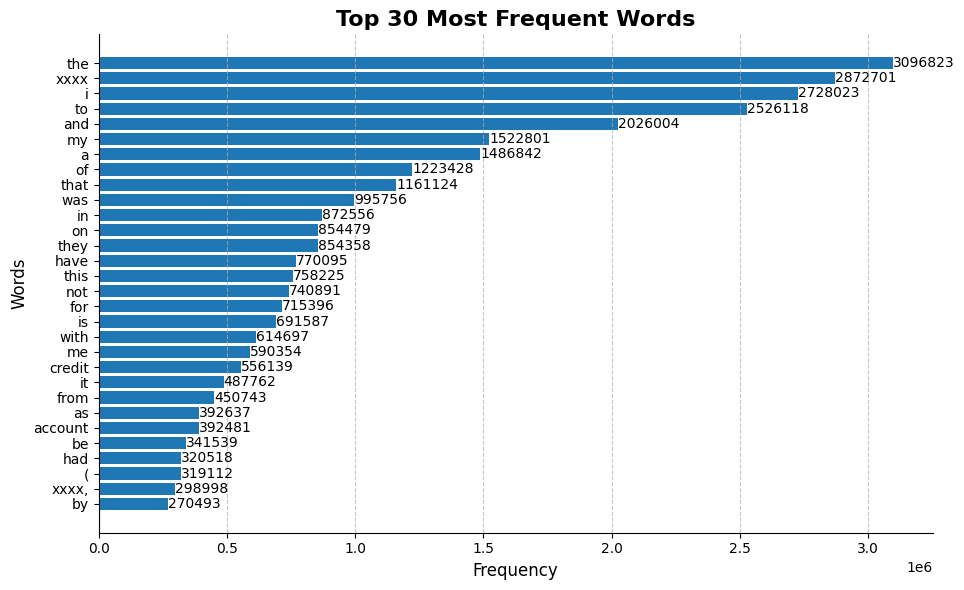

In [ ]:
words_plot = words[::-1]
counts_plot = counts[::-1]

plt.figure(figsize=(10, 6))

bars = plt.barh(words_plot, counts_plot)

plt.title("Top 30 Most Frequent Words", fontsize=16, weight="bold")
plt.xlabel("Frequency", fontsize=12)
plt.ylabel("Words", fontsize=12)

for i, v in enumerate(counts_plot):
    plt.text(v + 0.5, i, str(v), va="center", fontsize=10)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.subplots_adjust(left=.6)

plt.tight_layout()
plt.show()

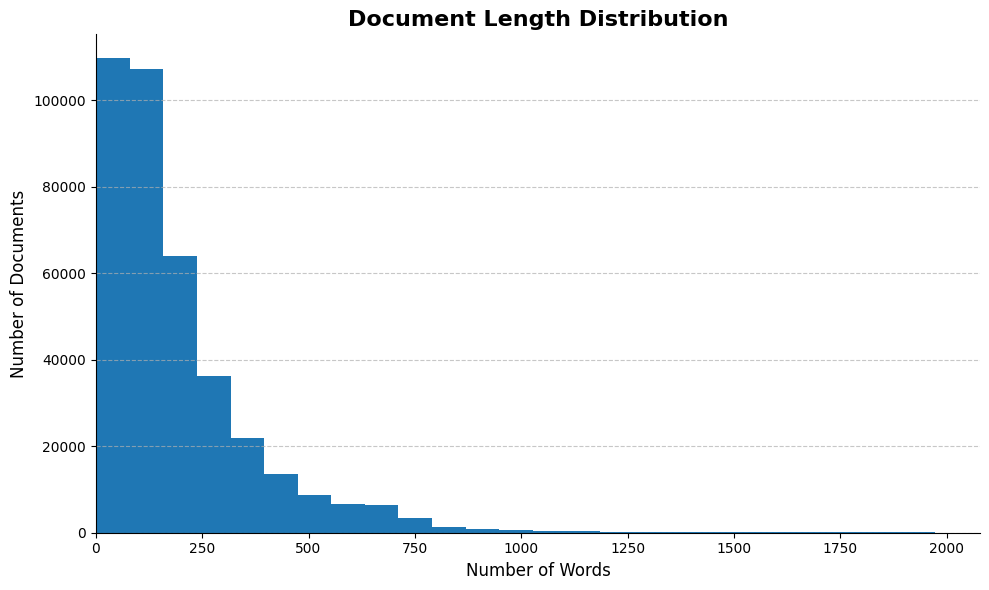

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(lengths, bins=80)

# Titles & labels
plt.title("Document Length Distribution", fontsize=16, weight="bold")
plt.xlabel("Number of Words", fontsize=12)
plt.ylabel("Number of Documents", fontsize=12)
plt.xlim(0, np.percentile(lengths, 99.9))

# Clean look
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

# Grid for readability
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Prevent cutting
plt.tight_layout()

plt.show()

In [ ]:
print("Total documents:", len(df_raw))
print("Average length:", lengths.mean())
print("Median length:", lengths.median())
print("Shortest document:", lengths.min())
print("Longest document:", lengths.max())

Total documents: 383564
Average length: 196.82238166251264
Median length: 136.0
Shortest document: 1
Longest document: 6314


In [ ]:
short_docs = (lengths < 20).sum()
print("Documents <20 words:", short_docs)
print("Top words:", list(words[:10]))

Documents <20 words: 13695
Top words: ['the', 'xxxx', 'i', 'to', 'and', 'my', 'a', 'of', 'that', 'was']


<small>

### Interpretation:
 -  Top raw words ('the', 'and', 'is') are stopwords — must be removed
 -  Domain words already visible: check category-specific terms after cleaning
 -  Long-tail length distribution is typical for support tickets

### Section 5 — Text Preprocessing

<span style="font-size: 13px;">
 Steps Applied

| Step | Code | Reason |
|---|---|---|
| **Lowercase** | `text.lower()` | `Login` and `login` are identical |
| **Remove non-alpha** | `re.sub(r"[^a-z\s]", " ")` | Numbers/punctuation add noise |
| **Remove stopwords** | `ENGLISH_STOP_WORDS` | Common words dilute topics |
| **Custom stop list** | Domain-specific words | Business words common to all categories |
| **Min word length** | `len(w) > 2` | Single-char tokens are meaningless |

**Business justification:**  
Without preprocessing, TF-IDF is dominated by grammatical words present in every complaint regardless of topic. After cleaning, only *discriminative* vocabulary remains.


In [ ]:
DOMAIN_STOPS = {
    "account", "company", "information", "consumer", "complaint",
    "financial", "bank", "told", "said", "call", "time", "year",
    "month", "day", "know", "need", "want", "make", "also", "would",
    "could", "got", "get", "one", "two", "three", "way", "back",
    "letter", "contact", "sent", "received", "response", "service",
    "money", "cash", "pay", "check", "fund", "use", "open"
}

ALL_STOPS = ENGLISH_STOP_WORDS.union(DOMAIN_STOPS)

In [ ]:
def lemmatize_batch(texts, batch_size=500):
    """Lemmatize a list of texts using spaCy in batches for speed."""
    results = []
    for doc in nlp.pipe(texts, batch_size=batch_size):
        tokens = [token.lemma_ for token in doc
                  if not token.is_space and len(token.lemma_) > 2]
        results.append(" ".join(tokens))
    return results

def preprocess(text):
    """Improved text preprocessing pipeline."""
    text = str(text).lower()
    text = re.sub(r"\bx{2,}\b", " ", text)        #  remove XXXX placeholders
    text = re.sub(r"\d+", " ", text)               #  remove all numbers
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = [w for w in text.split() if len(w) > 2 and w not in ALL_STOPS]
    return " ".join(tokens)


# Apply to all documents
df_raw["cleaned"] = df_raw["text"].apply(preprocess)

In [ ]:
df_raw["cleaned"] = lemmatize_batch(df_raw["cleaned"].tolist())

In [ ]:
df_clean = df_raw[df_raw["cleaned"].str.split().apply(len) >= 10].copy()
df_clean = df_clean.reset_index(drop=True)

In [ ]:
for cat in df_clean["category"].unique():
    row = df_clean[df_clean["category"] == cat].iloc[0]
    print(f"\n[{cat}]")
    print(f"BEFORE: {row['text'][:180].strip()!r}")
    print(f"AFTER : {row['cleaned'][:180].strip()!r}")
    print("-" * 80)


[Credit reporting, credit repair services, or other personal consumer reports]
BEFORE: 'The Summer of XX/XX/2018 I was denied a mortgage loan due to a charge off from XXXX XXXX credit card. I both mailed an account validation letter and disputed this debt with the cre'
AFTER : 'summer deny mortgage loan charge credit card mail validation dispute debt credit bureaus credit card time credit bureaus respond debt verify show proof request respond letter ask c'
--------------------------------------------------------------------------------

[Debt collection]
BEFORE: "Starting in XX/XX/XXXX I started receiving calls from ability recovery solutions regarding a Medical bill they claimed wasn't paid and I told them I was approved for SSI and Medica"
AFTER : 'start start receive call ability recovery solution regard medical claim wasn pay approve ssi medicaid fight year altogether backdate effective date medicaid hospital pull account c'
--------------------------------------------------------

In [ ]:
before_vocab = len(set(" ".join(df_raw["text"].astype(str).str.lower()).split()))
after_vocab = len(set(" ".join(df_clean["cleaned"]).split()))

In [ ]:
print(f"Vocabulary size:")
print(f"Before preprocessing: {before_vocab:,} unique words")
print(f"After preprocessing : {after_vocab:,} unique words")
print(f"Reduction: {(1-after_vocab/before_vocab)*100:.1f}%")
print(f"Documents kept: {len(df_clean)} / {len(df_raw)}")

Vocabulary size:
Before preprocessing: 278,295 unique words
After preprocessing : 96,314 unique words
Reduction: 65.4%
Documents kept: 358529 / 383564


### Section 6 — Feature Engineering: TF-IDF Document-Term Matrix


<span style="font-size: 13px;">

### What is TF-IDF?

$$\text{TF-IDF}(t, d) = \underbrace{\frac{\text{count of } t \text{ in } d}{\text{total words in } d}}_{\text{Term Frequency}} \times \underbrace{\log\frac{N}{\text{docs containing } t}}_{\text{Inverse Document Frequency}}$$

### The Document-Term Matrix

| Dimension | Meaning |
|---|---|
| **Rows** | Each customer complaint document |
| **Columns** | Each unique term in the vocabulary |
| **Cell value** | TF-IDF importance score |

**Why so sparse?** Each complaint uses only ~50–100 words out of a vocabulary of thousands.

In [ ]:
tfidf = TfidfVectorizer(
    max_features=15000,   # FIX: was 2000 — too small for 368k documents
    min_df=5,             # FIX: slightly higher to filter rare noise
    max_df=0.80,          # FIX: slightly tighter to remove near-universal terms
    ngram_range=(1, 2),   # FIX: was (1,1) — now captures "credit card", "student loan"
    stop_words=list(ALL_STOPS),  # FIX: use expanded stopword list
    sublinear_tf=True,    # NEW: log-scale TF dampens very frequent terms
)

In [ ]:
raw_docs = df_clean["cleaned"].tolist()
cat_labels = df_clean["category"].tolist()

In [ ]:
DTM = tfidf.fit_transform(raw_docs)  # (n_docs, n_terms)
terms = tfidf.get_feature_names_out()

In [ ]:
sparsity = 1 - DTM.nnz / (DTM.shape[0] * DTM.shape[1])

In [ ]:
print("TF-IDF DOCUMENT-TERM MATRIX")
print(f"Rows    (documents): {DTM.shape[0]:,}")
print(f"Columns (terms): {DTM.shape[1]:,}")
print(f"Non-zero entries: {DTM.nnz:,}")
print(f"Sparsity: {sparsity*100:.1f}%")

TF-IDF DOCUMENT-TERM MATRIX
Rows    (documents): 358,529
Columns (terms): 15,000
Non-zero entries: 21,438,409
Sparsity: 99.6%


<span style="font-size: 14px;">

## Interpretation:
- Each ROW = one complaint as a vector of TF-IDF scores
- Each COL = one term (word) from vocabulary
- Cell [i,j] = how important term j is to document i

In [ ]:
print(f"Sample terms: {list(terms[:15])}")

Sample terms: ['aadvantage', 'abandon', 'abide', 'ability', 'ability obtain', 'ability pay', 'ability recovery', 'able', 'able access', 'able afford', 'able answer', 'able assist', 'able close', 'able confirm', 'able continue']


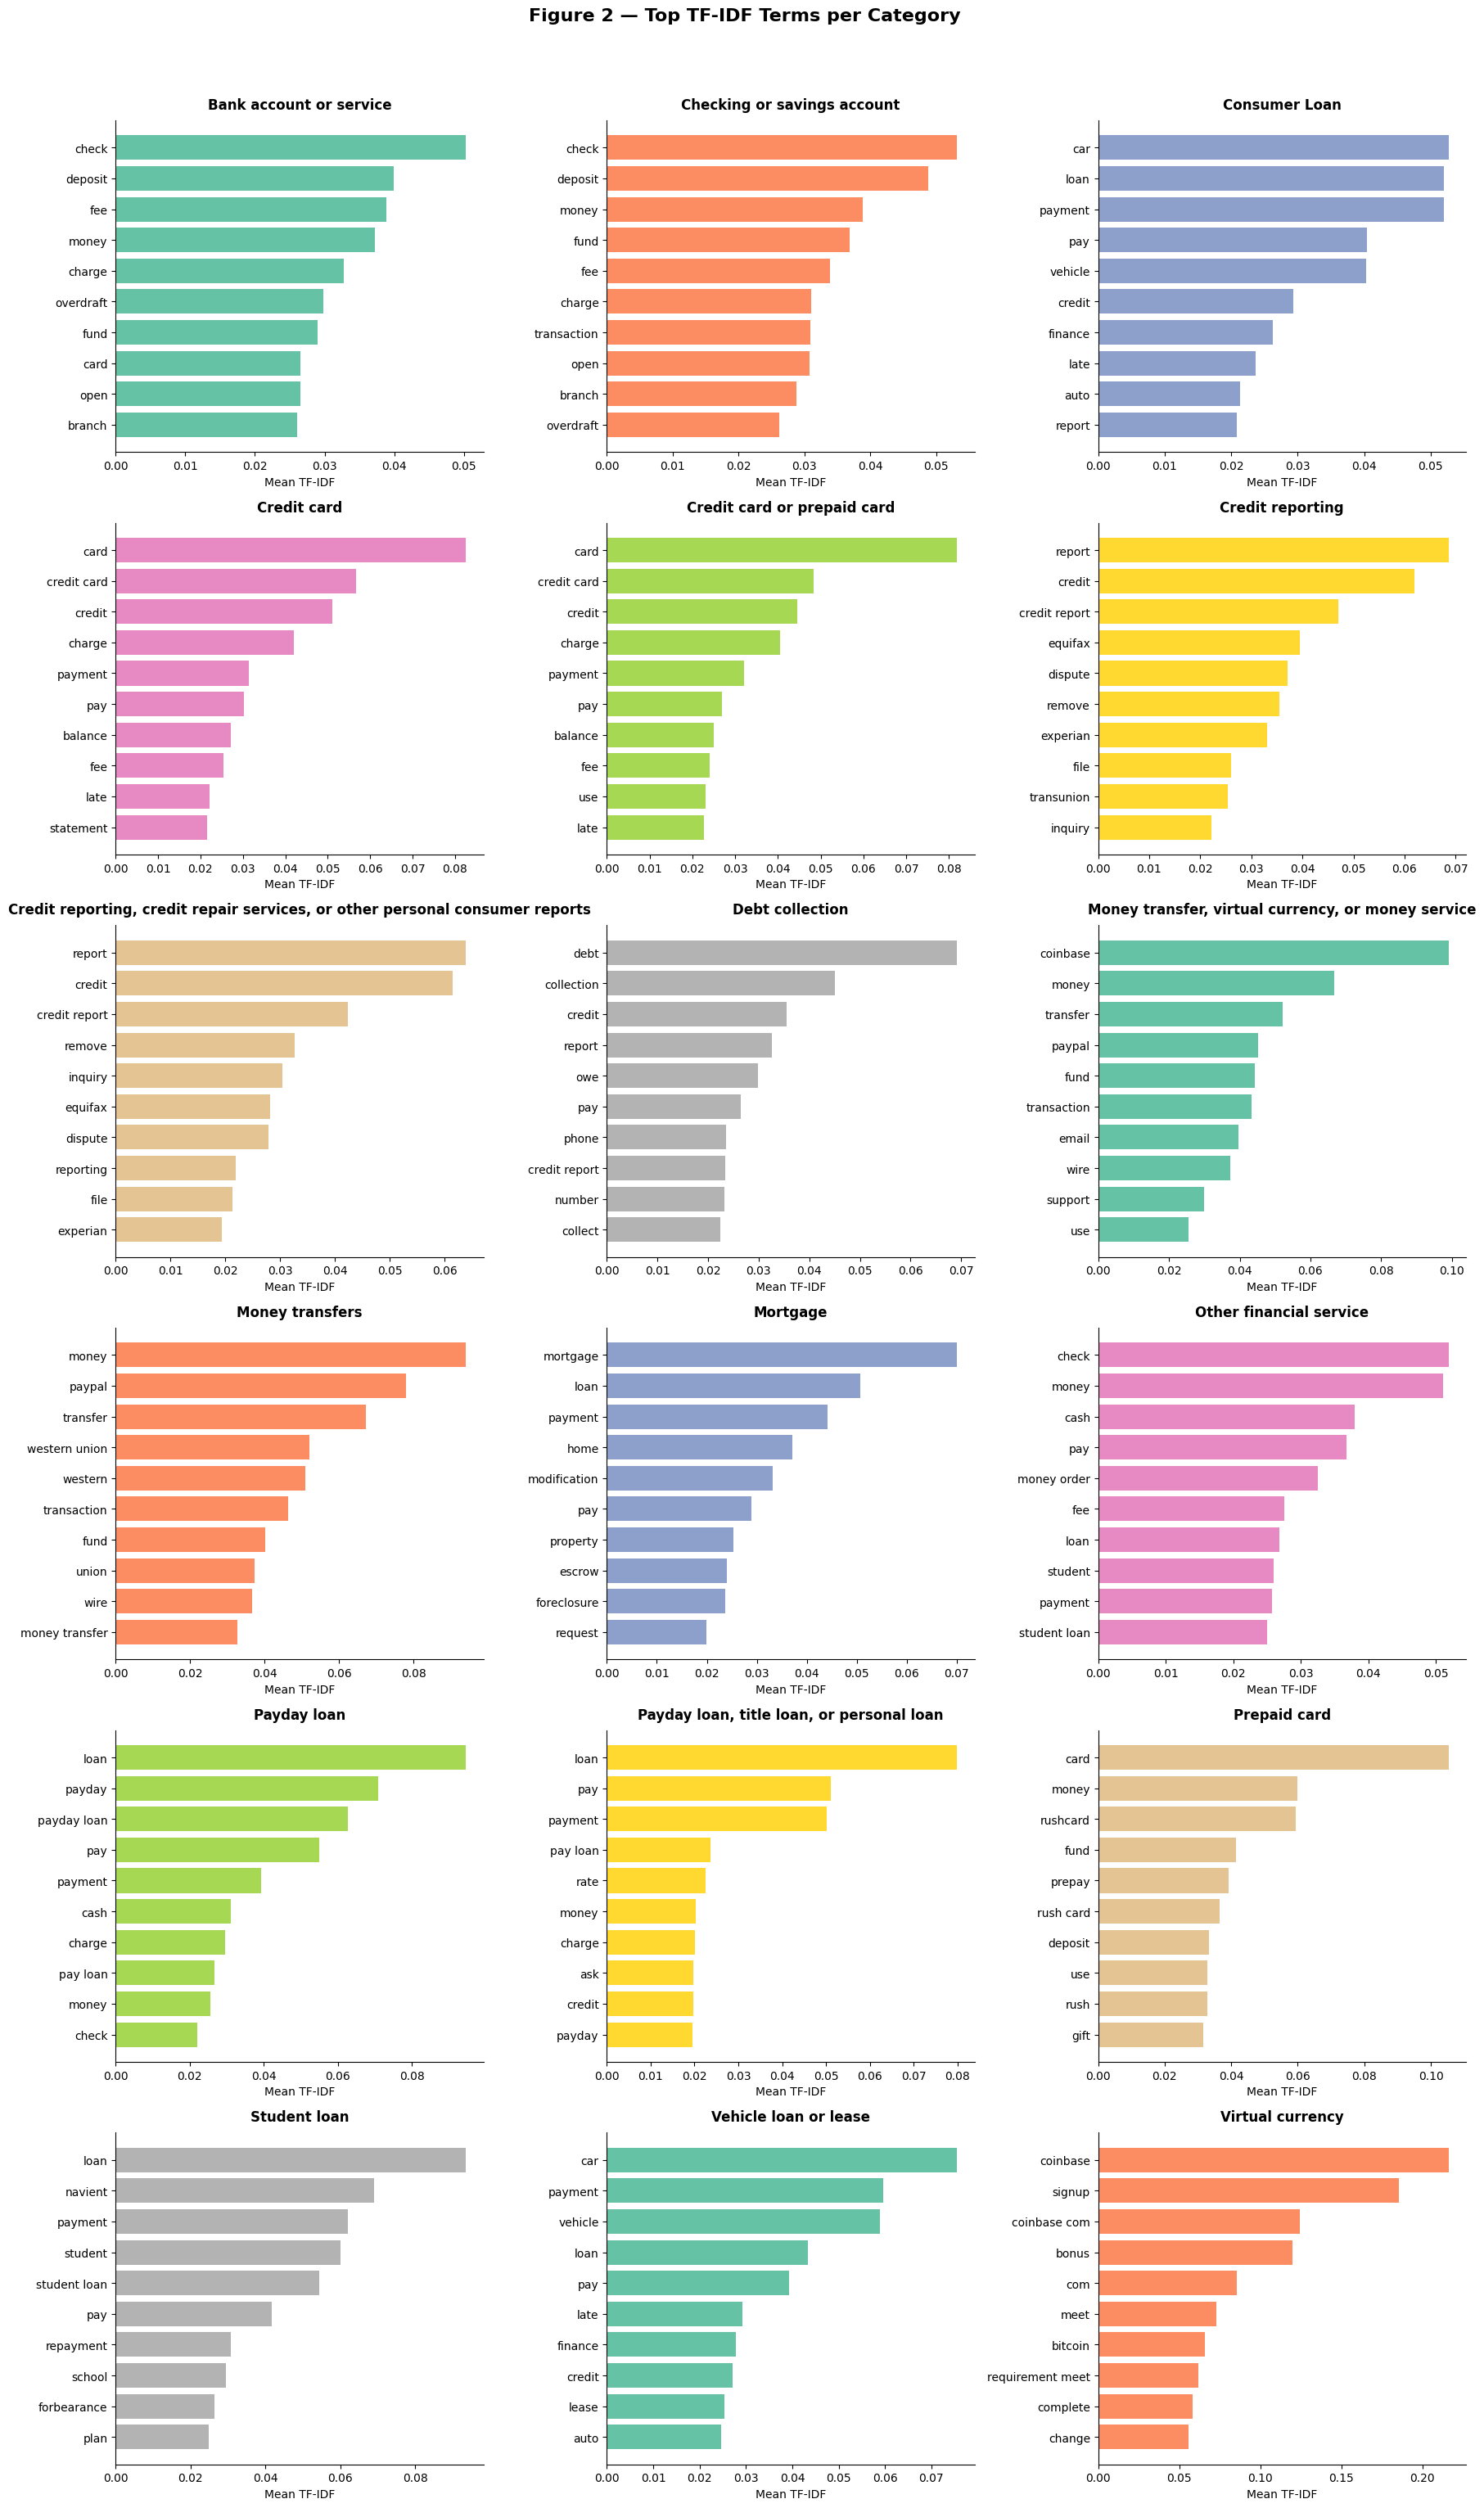

In [ ]:
categories = sorted(list(set(cat_labels)))
num_cats = len(categories)
cols = 3  # Set how many charts per row (3 is usually best for readability)
rows = math.ceil(num_cats / cols)

# Increase the overall figure size: (width, height)
# 18 units wide and 5 units per row provides plenty of room
fig, axes = plt.subplots(rows, cols, figsize=(18, 5 * rows))
axes = axes.flatten()  # Flatten the grid array for easy iteration

# 2. Iterate and Plot
for i, cat in enumerate(categories):
    ax = axes[i]

    # Calculate Mean TF-IDF for this category
    cat_idx = [idx for idx, label in enumerate(cat_labels) if label == cat]
    cat_mean = np.asarray(DTM[cat_idx].mean(axis=0)).flatten()


    top_indices = cat_mean.argsort()[::-1]

    # Optional: Filter out 'xxxx' if you want cleaner charts
    top_terms = []
    top_scores = []
    for idx in top_indices:
        term = terms[idx]
        if term != 'xxxx' and len(top_terms) < 10:
            top_terms.append(term)
            top_scores.append(cat_mean[idx])

    # Plotting
    ax.barh(
        top_terms[::-1], # Reversed for descending order top-to-bottom
        top_scores[::-1],
        color=sns.color_palette("Set2", num_cats)[i]
    )

    # Clean up the individual subplot titles and labels
    ax.set_title(cat.split("&")[0].strip(), fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Mean TF-IDF", fontsize=10)
    ax.tick_params(axis="y", labelsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 3. Handle Empty Subplots (if num_cats is not a multiple of cols)
for j in range(i + 1, len(axes)):
    axes[j].axis('off')

# 4. Final Formatting
fig.suptitle("Figure 2 — Top TF-IDF Terms per Category", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### Section 7 — Choosing k (Number of Latent Components)


<span style="font-size: 14px;">

### Strategy

We probe SVD with k=100 and plot cumulative explained variance.  
We select the **smallest k that captures ≥ 50% of total variance** — standard heuristic for LSA topic models.

| k too small | k too large |
|---|---|
| Topics blur together | Overfits noise, too granular |
| Loses important signal | No compression benefit |


In [ ]:
# Increase K_MAX to allow for more components to reach the variance threshold
K_MAX = min(300, DTM.shape[1] - 1)

In [ ]:
svd_probe = TruncatedSVD(
    n_components=K_MAX,
    random_state=42,
    n_iter=100
  )
svd_probe.fit(DTM)

TruncatedSVD(n_components=300, n_iter=100, random_state=42)

In [ ]:
# Calculate explained variance ratios
ind_var = svd_probe.explained_variance_ratio_
cum_var = np.cumsum(ind_var)

In [ ]:
# Added fallback: use elbow point or K_MAX if threshold is unreachable

k_50_idx = np.argmax(cum_var >= 0.50)
if cum_var[k_50_idx] >= 0.50:
    K = int(k_50_idx) + 1
    print(f"50% threshold reached → Chosen k = {K}  ({cum_var[K-1]*100:.1f}% variance)")
else:
    # Threshold not reachable — use elbow point (largest marginal drop in variance)
    marginal = np.diff(ind_var)
    elbow = int(np.argmin(marginal)) + 2   # +2 because diff shifts index by 1
    K = max(elbow, 100)                    # use at least 100 components
    print(f"50% threshold NOT reached within k={K_MAX}")
    print(f"Elbow point at k={elbow} → Using k = {K}  ({cum_var[K-1]*100:.1f}% variance)")

print(f"(Note: Low variance in diverse corpora is normal — LSA is still effective for retrieval)")

50% threshold NOT reached within k=300
Elbow point at k=3 → Using k = 100  (15.4% variance)
(Note: Low variance in diverse corpora is normal — LSA is still effective for retrieval)


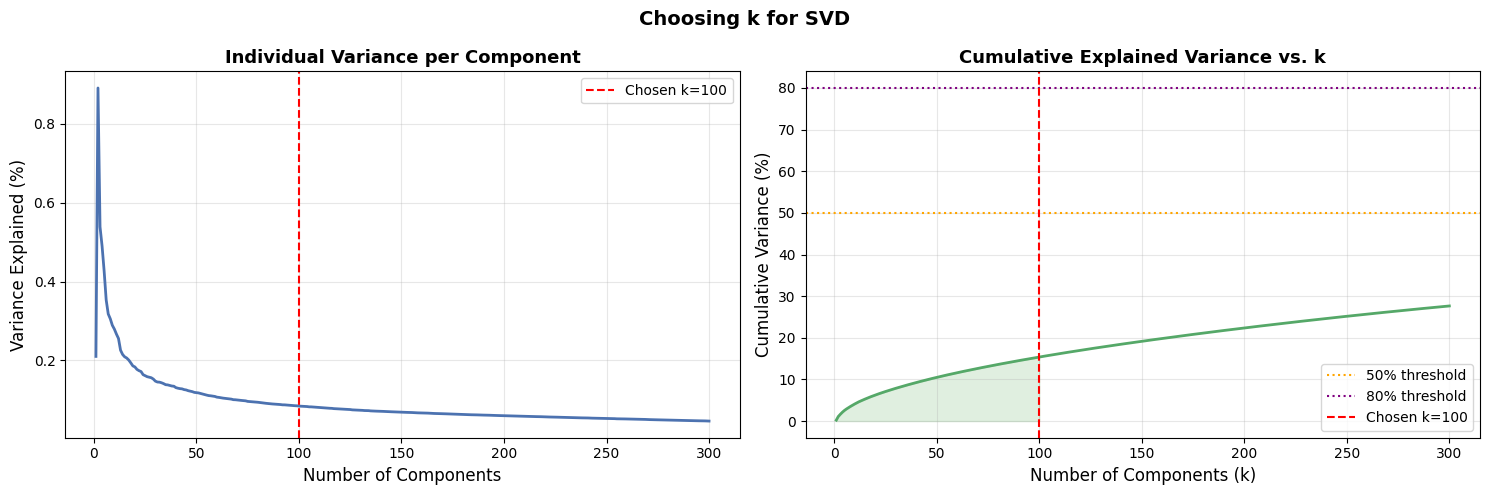

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(range(1, K_MAX + 1), ind_var * 100, color="#4C72B0", lw=2)
axes[0].axvline(K, color="red", ls="--", label=f"Chosen k={K}")
axes[0].set_xlabel("Number of Components", fontsize=12)
axes[0].set_ylabel("Variance Explained (%)", fontsize=12)
axes[0].set_title("Individual Variance per Component", fontsize=13, fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(range(1, K_MAX + 1), cum_var * 100, color="#55A868", lw=2)
axes[1].axhline(50, color="orange", ls=":", lw=1.5, label="50% threshold")
axes[1].axhline(80, color="purple", ls=":", lw=1.5, label="80% threshold")
axes[1].axvline(K, color="red", ls="--", label=f"Chosen k={K}")
axes[1].fill_between(range(1, K + 1), 0, cum_var[:K] * 100, alpha=0.12, color="green")
axes[1].set_xlabel("Number of Components (k)", fontsize=12)
axes[1].set_ylabel("Cumulative Variance (%)", fontsize=12)
axes[1].set_title("Cumulative Explained Variance vs. k", fontsize=13, fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle("Choosing k for SVD", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
k_checkpoints = [10, 20, 30, 50, 100, 150, 200, 300]
print("=" * 60)
print("VARIANCE CONCENTRATION ANALYSIS")
print("=" * 60)
for k_check in k_checkpoints:
    if k_check <= K_MAX:
        var_at_k = cum_var[k_check - 1] * 100
        print(f"k={k_check:3d}  →  {var_at_k:5.1f}% variance explained")

print(f"\nUsing k={K} explains {cum_var[K-1]*100:.1f}% variance")
print("=" * 60)

VARIANCE CONCENTRATION ANALYSIS
k= 10  →    4.1% variance explained
k= 20  →    6.2% variance explained
k= 30  →    7.9% variance explained
k= 50  →   10.5% variance explained
k=100  →   15.4% variance explained
k=150  →   19.2% variance explained
k=200  →   22.4% variance explained
k=300  →   27.6% variance explained

Using k=100 explains 15.4% variance


### Section 8 — Applying Singular Value Decomposition (Core Task)


<span style="font-size: 14px;">

### Mathematical Decomposition

$$A_{n \times m} \approx U_{n \times k} \; \Sigma_{k \times k} \; V^T_{k \times m}$$

| Matrix | Shape | Business Meaning |
|---|---|---|
| **U · Σ** | (n_docs × k) | Each complaint as a point in latent topic space |
| **Σ** | (k × k) | Importance/strength of each latent topic |
| **Vᵀ** | (k × n_terms) | Each topic as a weighted combination of terms |

### Why SVD Works for Text

- Words like `interest`, `rate`, `charge`, `fee` co-occur in billing complaints → SVD groups them into **one latent dimension** automatically
- Two complaints phrased differently but about the same issue → **close together** in latent space
- Noise and rare word variants → filtered out as low-variance dimensions


APPLY SVD  (Latent Semantic Analysis)

In [ ]:
# Re-run SVD with the updated K
svd = TruncatedSVD(n_components=K, random_state=42)
doc_topics = svd.fit_transform(DTM)
term_topics = svd.components_
sigma = svd.singular_values_
doc_topics_norm = normalize(doc_topics)

In [ ]:
print("SVD DECOMPOSITION RESULTS (Updated)")
print("=" * 55)
print(f"  Original DTM shape       : {DTM.shape}")
print(f"  U&Sigma;  (doc-topic matrix)  : {doc_topics.shape}")
print(f"       Each row = one complaint in {K}-dimensional latent space")
print(f"  Vᅠ   (term-topic matrix) : {term_topics.shape}")
print(f"  Variance retained : {cum_var[K-1]*100:.1f}%")
print(f"  Compression ratio : {DTM.shape[0]*DTM.shape[1]:,} → {doc_topics.shape[0]*doc_topics.shape[1]:,} values")

SVD DECOMPOSITION RESULTS (Updated)
  Original DTM shape       : (358529, 15000)
  U&Sigma;  (doc-topic matrix)  : (358529, 100)
       Each row = one complaint in 100-dimensional latent space
  Vᅠ   (term-topic matrix) : (100, 15000)
  Variance retained : 15.4%
  Compression ratio : 5,377,935,000 → 35,852,900 values


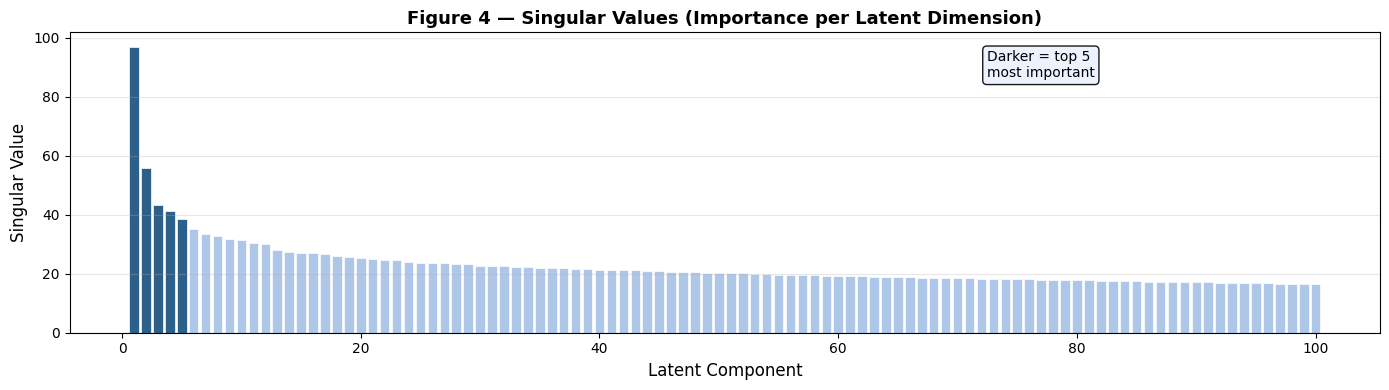

In [ ]:
# Singular values bar chart
fig, ax = plt.subplots(figsize=(14, 4))
bar_colors = ["#2C5F8A" if i < 5 else "#AEC6E8" for i in range(K)]
ax.bar(range(1, K + 1), sigma, color=bar_colors, edgecolor="white", lw=0.5)
ax.set_xlabel("Latent Component", fontsize=12)
ax.set_ylabel("Singular Value", fontsize=12)
ax.set_title(
    "Figure 4 — Singular Values (Importance per Latent Dimension)",
    fontsize=13,
    fontweight="bold",
)
ax.text(
    0.70,
    0.85,
    "Darker = top 5\nmost important",
    transform=ax.transAxes,
    fontsize=10,
    bbox=dict(boxstyle="round", facecolor="#EAF2FF", alpha=0.9),
)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Section 9 — Topic Discovery

<span style="font-size: 12px;">

#### How Topics Are Read from SVD

Each row of **Vᵀ** (`term_topics`) is a latent topic vector over all vocabulary terms.  
The terms with the **highest positive weights** define what each topic is about.

We show the **top 10 terms** per topic and provide a business interpretation.


TOPIC DISCOVERY

In [ ]:
N_TOPICS_SHOW = min(8, K)
TOP_N_WORDS = 10

In [ ]:
print("LATENT TOPICS DISCOVERED BY LSA (k=200)")
print("=" * 80)
print(f"{'Topic':<8} {'Top Words'}")
print("-" * 80)
for t in range(N_TOPICS_SHOW):
    top_idx = term_topics[t].argsort()[::-1][:TOP_N_WORDS]
    top_words = [terms[i] for i in top_idx]
    print(f"Topic {t+1:<2}  {', '.join(top_words)}")

LATENT TOPICS DISCOVERED BY LSA (k=200)
Topic    Top Words
--------------------------------------------------------------------------------
Topic 1   credit, report, payment, pay, credit report, debt, loan, card, dispute, remove
Topic 2   report, credit report, credit, remove, dispute, inquiry, debt, reporting, collection, equifax
Topic 3   debt, collection, owe, collect, collection agency, debt collection, agency, validation, collect debt, collector
Topic 4   loan, payment, late, mortgage, report, student, student loan, credit report, late payment, navient
Topic 5   debt, card, pay, late, collection, payment, credit card, charge, credit, balance
Topic 6   inquiry, loan, debt, hard, phone, hard inquiry, number, try, student, student loan
Topic 7   fargo, wells, wells fargo, inquiry, mortgage, hard, hard inquiry, credit report, home, credit
Topic 8   fargo, wells, wells fargo, theft, identity, identity theft, victim, victim identity, police, police report


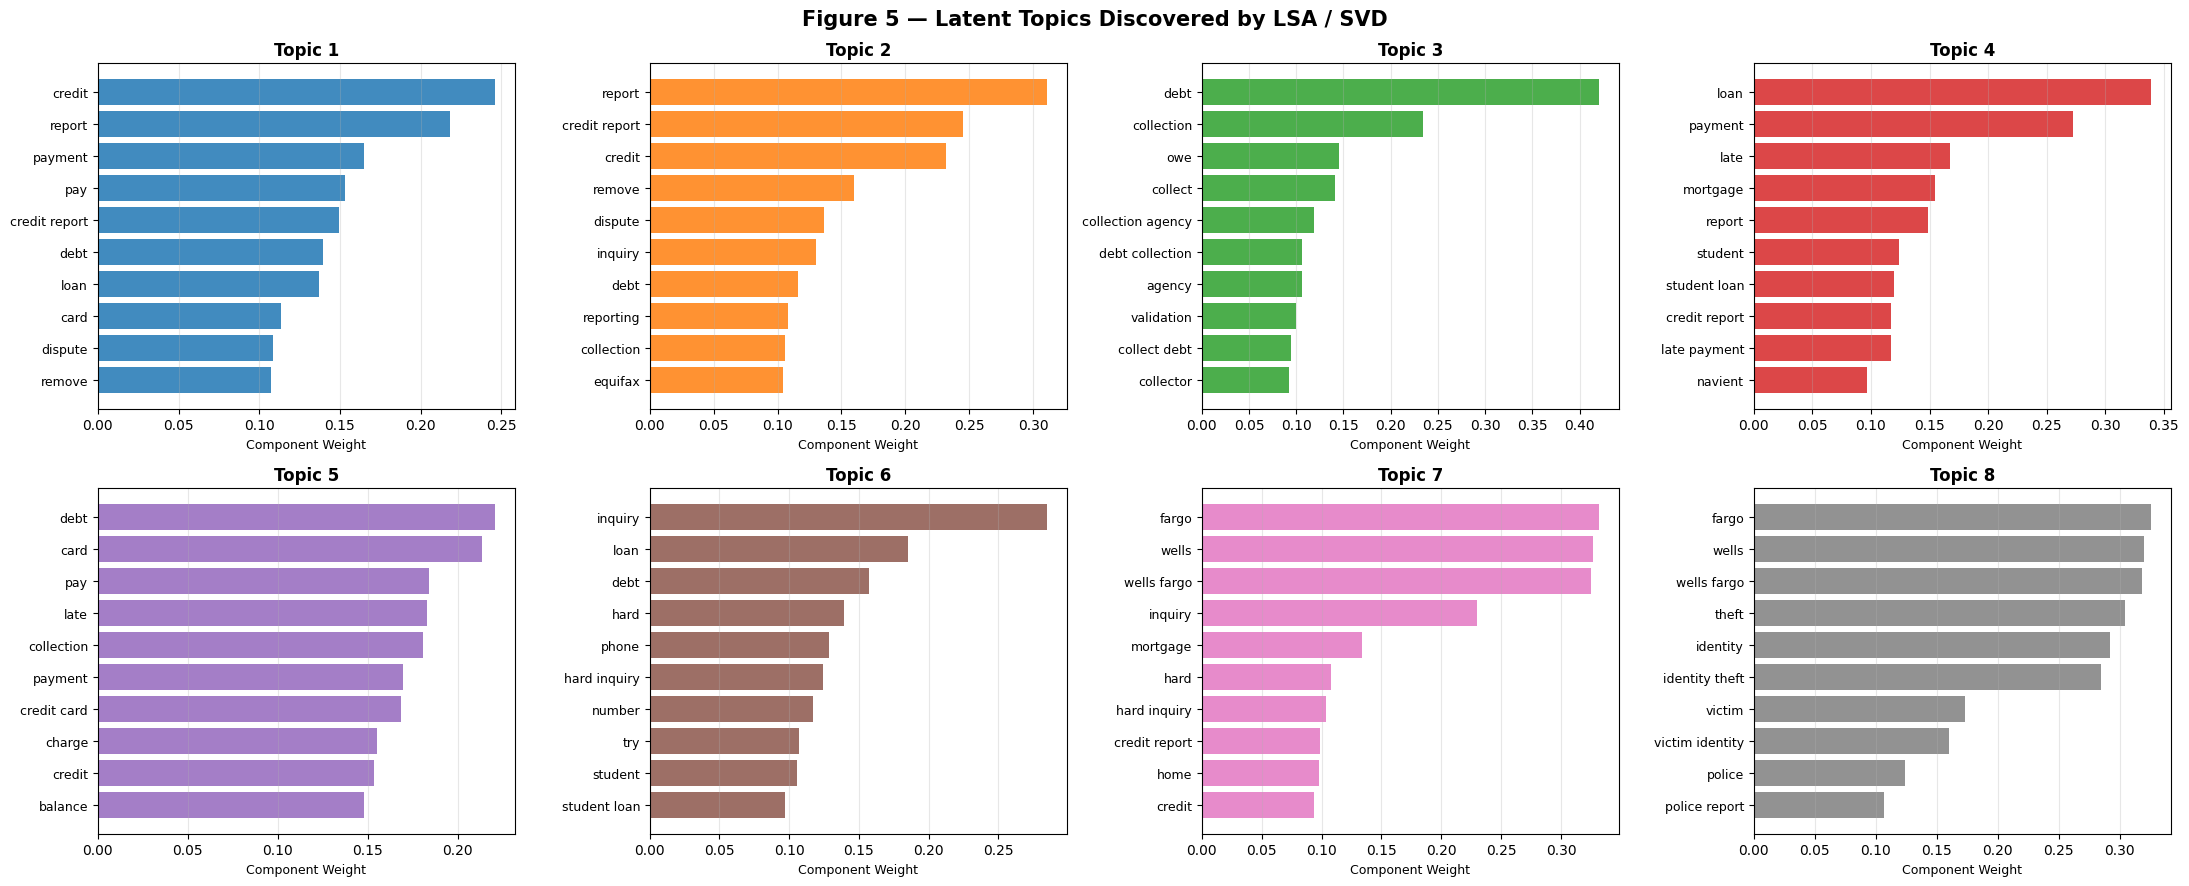

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(22, 9))
axes = axes.flatten()
palette = sns.color_palette("tab10", N_TOPICS_SHOW)

for t in range(N_TOPICS_SHOW):
    top_idx = term_topics[t].argsort()[::-1][:TOP_N_WORDS]
    top_words = [terms[i] for i in top_idx]
    top_scores = term_topics[t][top_idx]

    axes[t].barh(top_words[::-1], top_scores[::-1], color=palette[t], alpha=0.85)
    axes[t].set_title(f"Topic {t+1}", fontsize=12, fontweight="bold")
    axes[t].set_xlabel("Component Weight", fontsize=9)
    axes[t].tick_params(axis="y", labelsize=9)
    axes[t].grid(axis="x", alpha=0.3)

fig.suptitle(
    "Figure 5 — Latent Topics Discovered by LSA / SVD", fontsize=15, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [ ]:
topic_scores = pd.DataFrame(doc_topics, columns=[f"T{i+1}" for i in range(K)])
topic_scores["category"] = cat_labels
alignment = topic_scores.groupby("category").mean().iloc[:, :N_TOPICS_SHOW]
print(alignment.round(4).to_string())
print()
print(
    "Interpretation: The highest value in each row = the dominant topic for that category"
)

                                                                                  T1      T2      T3      T4      T5      T6      T7      T8
category                                                                                                                                    
Bank account or service                                                       0.1370 -0.0692 -0.0245 -0.0809 -0.0073 -0.0245  0.0158  0.0122
Checking or savings account                                                   0.1388 -0.0711 -0.0234 -0.0908 -0.0142 -0.0247  0.0126  0.0100
Consumer Loan                                                                 0.1496 -0.0548 -0.0075  0.0294  0.0144  0.0103 -0.0041  0.0017
Credit card                                                                   0.1593 -0.0417 -0.0568 -0.0646  0.0527 -0.0217 -0.0024 -0.0038
Credit card or prepaid card                                                   0.1586 -0.0503 -0.0572 -0.0695  0.0449 -0.0242 -0.0058 -0.0074
Credit report

### Section 10 — Finding Similar Customer Complaints

<span style="font-size: 14px;">

### Method: Cosine Similarity in Latent Space

$$\text{similarity}(d_1, d_2) = \frac{\vec{d_1} \cdot \vec{d_2}}{\|\vec{d_1}\| \cdot \|\vec{d_2}\|}$$

| Score | Business Meaning |
|---|---|
| **> 0.90** | Near-duplicate — auto-merge into one ticket |
| **0.70–0.90** | Same issue, different phrasing — link as related |
| **0.40–0.70** | Same category, different sub-issue |
| **< 0.40** | Different complaint types |

### Why Latent Similarity Beats Keyword Search

Two complaints may use **completely different words** but describe the **same underlying problem**.  
LSA finds them as similar because they share the same latent topic coordinates — keyword search would miss them entirely.


DOCUMENT SIMILARITY — HEATMAP & CATEGORY ANALYSIS

In [ ]:
# FIX: was 300 — too small to represent 368k documents reliably
SAMPLE = min(3000, len(raw_docs))
rng = np.random.default_rng(42)
idx = rng.choice(len(raw_docs), SAMPLE, replace=False)

sample_vecs = doc_topics_norm[idx]
sample_labels = [cat_labels[i] for i in idx]
short_labels = [l.split("&")[0].strip()[:12] for l in sample_labels]

sim_matrix = cosine_similarity(sample_vecs)

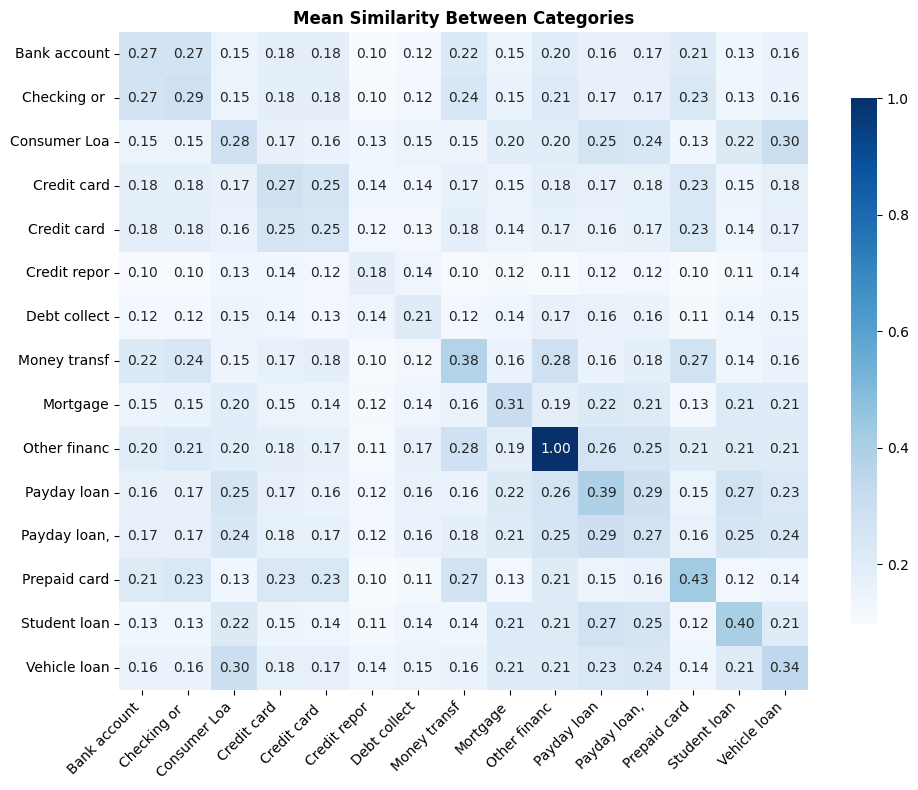

In [ ]:
# Category-level average similarity
unique_cats = sorted(set(short_labels))
cat_idx_map = {c: [j for j, l in enumerate(short_labels) if l == c] for c in unique_cats}
n_cats = len(unique_cats)
cat_sim = np.zeros((n_cats, n_cats))

for i, ca in enumerate(unique_cats):
    for j, cb in enumerate(unique_cats):
        vals = sim_matrix[np.ix_(cat_idx_map[ca], cat_idx_map[cb])]
        cat_sim[i, j] = vals.mean()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    cat_sim,
    cmap="Blues",
    xticklabels=unique_cats,
    yticklabels=unique_cats,
    annot=True,
    fmt=".2f",
    cbar_kws={"shrink": 0.8},
)
plt.title("Mean Similarity Between Categories", fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)  # optional: keep y-axis labels horizontal
plt.tight_layout()
plt.show()

In [ ]:
sim_copy = sim_matrix.copy()
np.fill_diagonal(sim_copy, 0)
flat = sim_copy.flatten()
top_flat = flat.argsort()[::-1]

seen, similar_pairs = set(), []
for p in top_flat:
    r, c = divmod(p, SAMPLE)
    key = tuple(sorted((r, c)))
    if key not in seen:
        seen.add(key)
        similar_pairs.append((idx[r], idx[c], sim_copy[r, c]))
    if len(similar_pairs) == 5:
        break

In [ ]:
print("TOP 5 MOST SIMILAR COMPLAINT PAIRS (k=200 Latent Space)")
for rank, (a, b, score) in enumerate(similar_pairs, 1):
    print(f"\n{'─'*75}")
    print(f"  Pair {rank}  |  Cosine Similarity = {score:.4f}")
    print(f"  Complaint #{a:4d}  [{cat_labels[a]}]")
    print(f"    '{df_clean.iloc[a]['text'][:160].strip()}...'")
    print(f"  Complaint #{b:4d}  [{cat_labels[b]}]")
    print(f"    '{df_clean.iloc[b]['text'][:160].strip()}...'")

TOP 5 MOST SIMILAR COMPLAINT PAIRS (k=200 Latent Space)

───────────────────────────────────────────────────────────────────────────
  Pair 1  |  Cosine Similarity = 1.0000
  Complaint #267566  [Credit reporting]
    'I am filing this complaint because TransUnion has ignored my request to provide me with the documents that their company has on file that was used to verify the...'
  Complaint #269778  [Credit reporting]
    'I am filing this complaint because TransUnion has ignored my request to provide me with the documents that their company has on file that was used to verify the...'

───────────────────────────────────────────────────────────────────────────
  Pair 2  |  Cosine Similarity = 1.0000
  Complaint #186182  [Credit card or prepaid card]
    'I was shocked when I reviewed my credit report and found late payment on the dates below : 30 days past due as of  XXXX   2012 ,  XXXX   2012  I am not sure how...'
  Complaint #217394  [Mortgage]
    'I was shocked when I reviewed my

### Section 11 — Document Visualisation in 2D Latent Space

<span style="font-size: 12px;">

Projecting all complaints onto the first two SVD dimensions gives us a **2D semantic map** of the complaint landscape.  
Each point is one complaint, coloured by its category.


Running t-SNE on 200 dimensions... (~1–2 min)
Done.


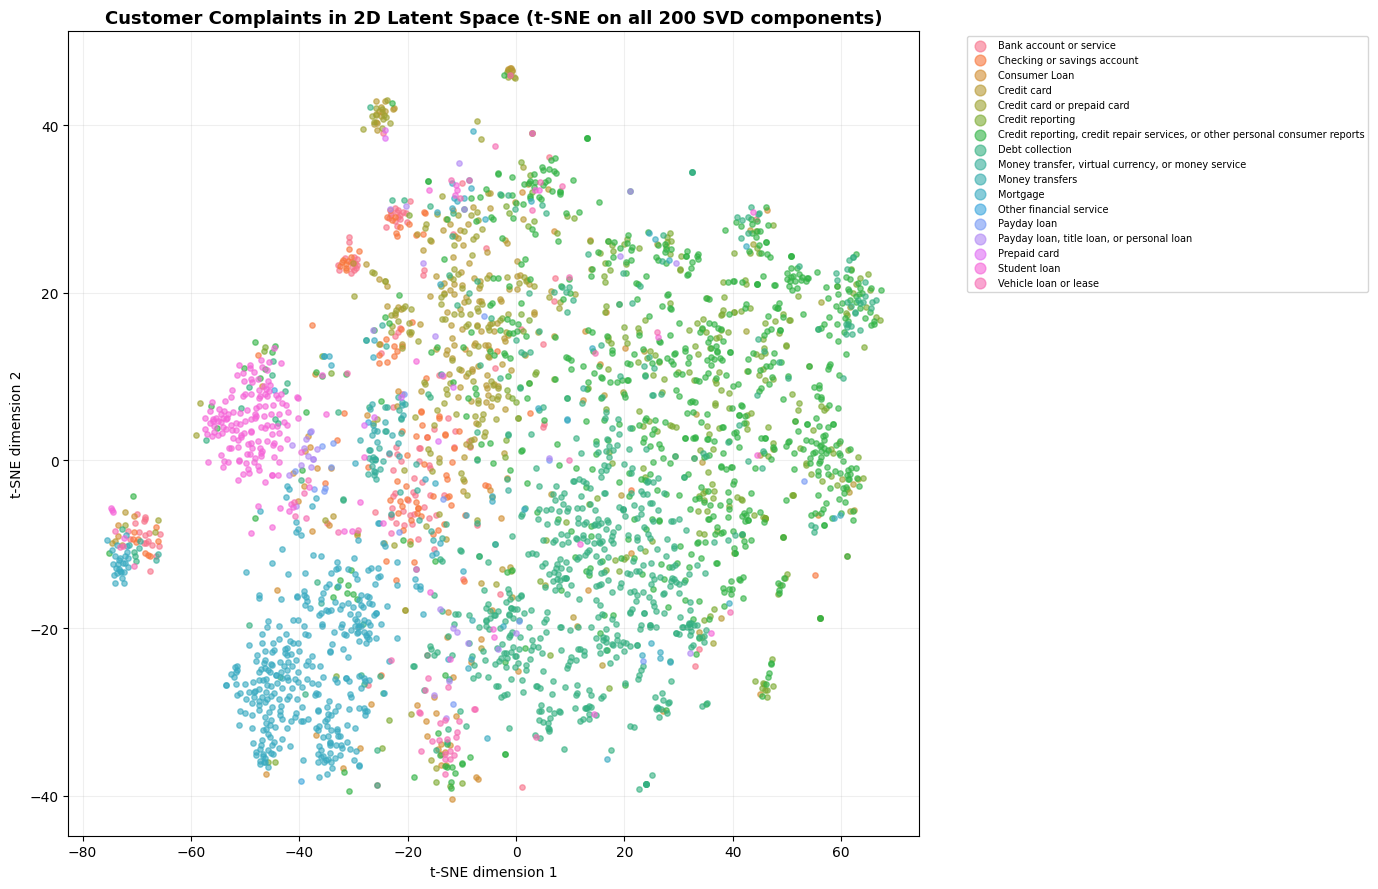

In [ ]:
from sklearn.manifold import TSNE

# Sample for speed — t-SNE is slow on large datasets
VIZ_SAMPLE = 3000
rng_viz = np.random.default_rng(99)
viz_idx = rng_viz.choice(len(raw_docs), VIZ_SAMPLE, replace=False)

viz_vecs  = doc_topics_norm[viz_idx]       # all 200 dims go in
viz_labels = [cat_labels[i] for i in viz_idx]

print("Running t-SNE on 200 dimensions... (~1–2 min)")
tsne = TSNE(
    n_components=2,
    perplexity=40,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    n_jobs=-1
)
tsne_coords = tsne.fit_transform(viz_vecs)
print("Done.")

# Plot
fig, ax = plt.subplots(figsize=(14, 9))
palette   = sns.color_palette("husl", len(set(viz_labels)))
cat_list  = sorted(set(viz_labels))
color_map = {c: palette[i] for i, c in enumerate(cat_list)}

for cat in cat_list:
    mask = [l == cat for l in viz_labels]
    xs = tsne_coords[mask, 0]
    ys = tsne_coords[mask, 1]
    ax.scatter(xs, ys, label=cat, s=15, alpha=0.6, color=color_map[cat])

ax.set_title(
    "Customer Complaints in 2D Latent Space (t-SNE on all 200 SVD components)",
    fontweight="bold", fontsize=13
)
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=7, markerscale=2)
ax.grid(alpha=0.2)
plt.tight_layout()
plt.show()

<span style="font-size: 14px;">

### Interpreting the Latent Space Plot
-  Tight clusters = LSA successfully separated complaint domains
-  Overlapping categories = complaints that genuinely span two topics
- Outliers = unusual/unique complaints that don't fit the main themes

### Section 12 — Semantic Query Search

<span style="font-size: 14px;">

A practical production feature: given a **new incoming complaint**, instantly find the most similar existing tickets using LSA — even if they use completely different words.


In [ ]:
def find_similar_complaints(query, top_k=3):
    # Vectorize and project query into the same 200-dim LSA space
    cleaned_q = preprocess(query)
    tfidf_q = tfidf.transform([cleaned_q])
    lsa_q = svd.transform(tfidf_q)
    lsa_q_norm = normalize(lsa_q)

    # Calculate cosine similarity against all 360k+ documents
    sims = cosine_similarity(lsa_q_norm, doc_topics_norm).flatten()
    top_idx = sims.argsort()[::-1][:top_k]

    print(f"QUERY: '{query}'")
    print("="*80)
    for i in top_idx:
        print(f"[Score: {sims[i]:.3f}] Category: {cat_labels[i]}")
        print(f"Text: {df_clean.iloc[i]['text'][:200]}...")
        print("-"*80)

In [ ]:
print("CREDIT REPORTING ERROR")
print("="*80)
find_similar_complaints(
    "false negative information is appearing on my credit report. Account was paid off years ago but it still shows as delinquent. I have contacted the credit bureau multiple times to dispute it but they refuse to remove it."
)

CREDIT REPORTING ERROR
QUERY: 'false negative information is appearing on my credit report. Account was paid off years ago but it still shows as delinquent. I have contacted the credit bureau multiple times to dispute it but they refuse to remove it.'
[Score: 0.870] Category: Credit reporting, credit repair services, or other personal consumer reports
Text: When I was notified by  XXXX    XXXX   which purchased the account from  XXXX   XXXX  that I had a voluntary auto repossession account with them, I disputed this account. Then I notified the  XXXX  cr...
--------------------------------------------------------------------------------
[Score: 0.870] Category: Credit reporting, credit repair services, or other personal consumer reports
Text: When I was notified by   XXXX   XXXX   which purchased the account from   XXXX   XXXX   that I had a voluntary auto repossession account with them, I disputed this account. Then I notified the  XXXX  ...
-------------------------------------------

In [ ]:
print("STUDENT LOAN REPAYMENT ISSUE")
find_similar_complaints(
    "I have been trying to enroll in an income driven repayment plan for my federal student loans but the servicer keeps denying my application. I submitted the paperwork three times and they keep saying it is lost."
)

STUDENT LOAN REPAYMENT ISSUE
QUERY: 'I have been trying to enroll in an income driven repayment plan for my federal student loans but the servicer keeps denying my application. I submitted the paperwork three times and they keep saying it is lost.'
[Score: 0.917] Category: Student loan
Text: Over the course of the loan which has been o ver ten years  customer service only give information about deferment and forbearance. I found out about income base repayment plans from a coworker. I hav...
--------------------------------------------------------------------------------
[Score: 0.906] Category: Student loan
Text: The company, FedLoan Servicin g ( " FedLoan '' ), is se rvicing my federal student loan. I am making payments und er the Public Service Loan Forgiveness Program and having  a payment each month under ...
--------------------------------------------------------------------------------
[Score: 0.904] Category: Student loan
Text: From the moment I went into loan repayment, I eng

In [ ]:
print("BANK ACCOUNT OVERDRAFT FEES")
find_similar_complaints(
    "my bank charged me overdraft fees multiple times on the same day. I had insufficient funds but they processed several charges out of order to maximize fees. The overdraft charges were excessive and unfair."
)

BANK ACCOUNT OVERDRAFT FEES
QUERY: 'my bank charged me overdraft fees multiple times on the same day. I had insufficient funds but they processed several charges out of order to maximize fees. The overdraft charges were excessive and unfair.'
[Score: 0.920] Category: Bank account or service
Text: I am opted out of overdraft protection at BB & T. I have been charged an overdraft fee on numerous occasions, even as i have been opted out of all overdraft protection for over 30 days. I would like t...
--------------------------------------------------------------------------------
[Score: 0.914] Category: Bank account or service
Text: My bank account unexpectedly became overdrawn last night by {$1.00} due to the fact that a {$30.00} mobile deposit was not credited. A couple concerns are ; ( 1 ) I did n't think a bank could charge a...
--------------------------------------------------------------------------------
[Score: 0.914] Category: Checking or savings account
Text: My SunTrust checki

### Section 13 — Business Conclusions & Recommendations

<span style="font-size: 13px;">

### What LSA Discovered

| Finding | Business Action |
|---|---|
| **Distinct complaint domains separated automatically** | Build category-specific response queues per topic |
| **Topics reveal sub-themes** (e.g. hardware vs software) | Route tickets to specialised teams |
| **High-similarity complaint pairs identified** | Auto-merge duplicate tickets, save agent time |
| **Cross-category overlaps found** | Create hybrid routing rules for borderline complaints |
| **Rare outlier complaints detected** | Flag for senior agent review — may indicate new emerging issues |

### LSA vs. Other Approaches

| Method | Strength | Limitation | Best Use Case |
|---|---|---|---|
| **LSA (this project)** | No labels, fast, semantic | Linear only | First-pass topic discovery |
| **LDA** | Probabilistic, interpretable | Slow, needs tuning | When you need topic probabilities |
| **BERT Embeddings** | State-of-the-art accuracy | Needs GPU, large model | Production high-accuracy systems |
| **Keyword Rules** | Fast, explainable | Misses paraphrasing | Simple well-defined categories only |

### Recommended Next Steps

1. **Deploy LSA pipeline** on live complaint stream with weekly retraining
2. **Build incident alert** — trigger when 10+ similar complaints appear within 1 hour
3. **A/B test** LSA auto-routing vs. manual triage — measure resolution time improvement
4. **Collect labels** from agents over 6 months → upgrade to supervised model (BERT fine-tune)
5. **Expand to bigrams/trigrams** — phrases like "cannot log in" carry more meaning than individual words

---

> *SVD / LSA transforms thousands of unstructured customer complaints into a structured, searchable semantic space — enabling automatic topic discovery, duplicate detection, and intelligent routing without any manual labelling.*
